# Model Evaluation 

## Financial Metrics for best model

Algorithm | AUROC | Gini | KS | AUPRC | Best threshold | F1 (optimal)
----------|-------|------|----|-------|----------------|-------------
Random Forest | 0.740348 | 0.480696 | 0.373052 | 0.159603 | 0.50 | 0.244211

## Run StratifiedKFold CV (5 folds) on your best pipeline. Report mean and std of AUROC. Is performance stable across folds?

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import shap
import os
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

In [2]:
# load best pipeline
best_model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")
with open(best_model_path, mode='rb') as f:
    best_model = joblib.load(f)

df_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df = pd.read_csv(df_path)

df = df.drop(columns=['Unnamed: 0', 'SK_ID_CURR'])

In [3]:
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X, y = df.drop(columns=['TARGET']), df['TARGET']
scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc')
display(np.mean(scores))
display(np.std(scores))
display(scores)

0.7402246851161669

0.013827862100827292

array([0.73498664, 0.73872021, 0.75690849, 0.75255411, 0.71795398])

The results across the folds are consistent and stable performance wise. AUROC is across 0.7 and with little variability across folds

## 3. Generate SHAP values for 1,000 random test samples (full test set may be slow). Create: (a) SHAP summary beeswarm plot, (b) SHAP bar plot of mean |SHAP| by feature.

In [5]:
from shap import Explainer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_sample = X_test.sample(n=1000, random_state=42)

In [6]:
X_sample

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y
4285,0,112500.0,454500.0,16452.0,454500.0,0.007020,-10707,-1690.0,-9101.0,-1083,...,1,0,0,0,1,1,0,1,0,1
12633,2,180000.0,733315.5,39069.0,679500.0,0.018801,-14951,-213.0,-3239.0,-6058,...,1,0,0,0,1,1,0,1,0,1
3312,0,225000.0,560664.0,16195.5,468000.0,0.035792,-11096,-3063.0,-5074.0,-3583,...,1,0,0,1,0,1,0,1,0,1
9064,1,180000.0,1071000.0,34677.0,1071000.0,0.031329,-17498,-3266.0,-3767.0,-1037,...,1,0,0,0,1,1,0,1,0,1
6336,0,202500.0,659610.0,21406.5,472500.0,0.072508,-16832,-2385.0,-4309.0,-389,...,1,0,0,0,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1690,0,540000.0,675000.0,53460.0,675000.0,0.022625,-11673,-629.0,-4221.0,-2714,...,1,0,0,0,1,1,0,1,0,1
2864,0,315000.0,1125000.0,29808.0,1125000.0,0.025164,-19602,-4334.0,-6757.0,-3156,...,1,0,0,1,0,1,0,1,0,1
9757,2,126000.0,260640.0,31059.0,225000.0,0.006629,-14254,-910.0,-1535.0,-2558,...,1,0,0,1,0,0,1,1,0,1
286,1,270000.0,675000.0,36616.5,675000.0,0.025164,-13785,-2930.0,-3088.0,-3088,...,1,0,0,0,1,1,0,1,0,1


In [7]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

# transform the sample according to the pipeline transformer
X_sample_normalized = preprocessor.transform(X_sample)

# convert transformed array into Dataframe and rename the columns so SHAP plots have feature names and not just numbers
X_sample_normalized = pd.DataFrame(X_sample_normalized)
X_sample_normalized.columns = X_sample.columns

In [8]:
X_sample_normalized

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y
0,-0.746791,-0.761879,-0.529746,-0.898644,-0.420631,-1.014706,1.040378,0.262498,-1.495875,1.217103,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0
1,1.871319,-0.283483,0.066184,0.428697,0.098857,-0.325599,-0.148302,1.005402,0.352210,-2.032084,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0
2,-0.746791,0.035448,-0.302835,-0.913697,-0.389462,0.668256,0.931425,-0.428097,-0.226302,-0.415654,...,0.103711,-0.07472,-0.071523,1.484972,-1.484972,0.089914,-0.089914,0.360296,-0.360296,0.0
3,0.562264,-0.283483,0.787938,0.170940,1.002766,0.407202,-0.861678,-0.530202,0.185750,1.247146,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0
4,-0.746791,-0.124018,-0.091351,-0.607875,-0.379072,2.815887,-0.675142,-0.087075,0.014876,1.670356,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.746791,2.267961,-0.058457,1.273271,0.088467,-0.101922,0.769816,0.796162,0.042620,0.151892,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0
996,-0.746791,0.673309,0.903356,-0.114810,1.127443,0.046592,-1.450977,-1.067388,-0.756893,-0.136779,...,0.103711,-0.07472,-0.071523,1.484972,-1.484972,0.089914,-0.089914,0.360296,-0.360296,0.0
997,1.871319,-0.666199,-0.944095,-0.041392,-0.950509,-1.037577,0.046917,0.654824,0.889422,0.253776,...,0.103711,-0.07472,-0.071523,1.484972,-1.484972,-11.121704,11.121704,0.360296,-0.360296,0.0
998,0.562264,0.354378,-0.058457,0.284765,0.088467,0.046592,0.178277,-0.361200,0.399815,-0.092368,...,0.103711,-0.07472,-0.071523,-0.673414,0.673414,0.089914,-0.089914,0.360296,-0.360296,0.0


In [9]:
# read in values if the file exists
shap_path = Path(f"{os.getcwd()}/../models/shap_values.joblib")

if shap_path.exists():
    shap_values = joblib.load(shap_path)
else:
    explainer = shap.Explainer(model, X_sample_normalized)
    shap_values = explainer(X_sample_normalized)
    joblib.dump(shap_values, shap_path)

### Beeswarm plot

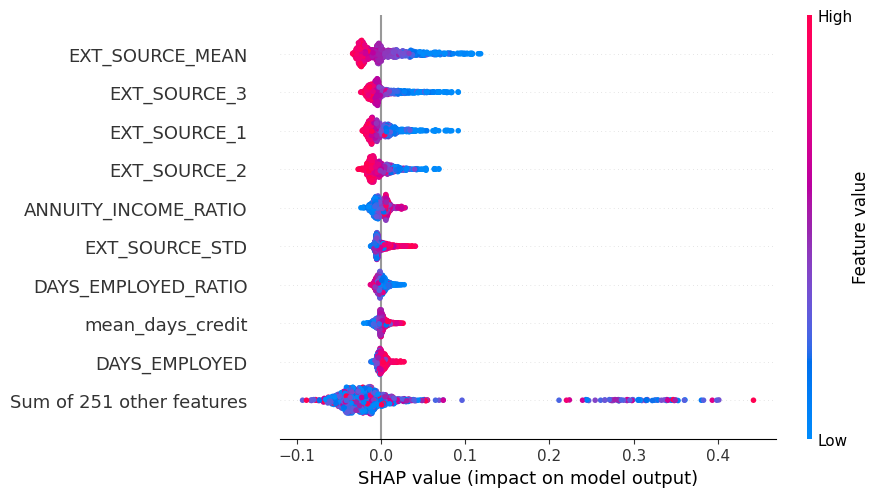

In [10]:
# the beeswarm function expects a 2D array, not 3D - pick the positive class
shap.plots.beeswarm(shap_values[:, :, 1])

We know that a feature whose dots are spread out more evenly along the x-axis has higher importance. Based on this knowledge, we see that the three external normalized credit scores are the most important, which makes their average also very important in determining whether or not an applicant is going to default. This makes sense, since a source's credit score is itself based on many factors and reflect's the applicant's propensity to pay back their loans on time.

### Bar plot of mean |SHAP|

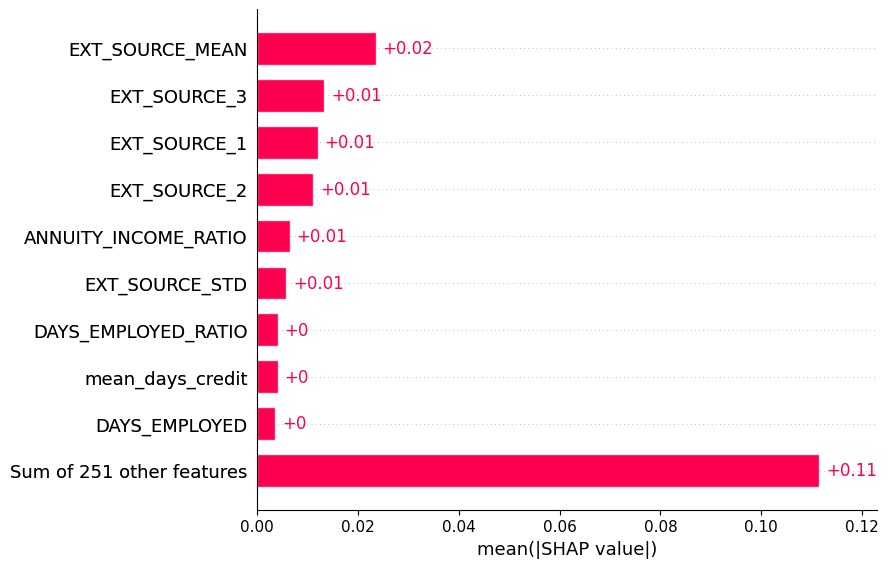

In [11]:
shap.plots.bar(shap_values[..., 1])

## Select 3 individual applicants: one high-risk (predicted PD > 0.5), one borderline (PD 0.2–0.4), one low-risk (PD < 0.1). Generate SHAP waterfall plots for each.

We need to pick three applicants, one with predicted probability > 0.5 (most likely to default), one medium risk (predicted probability 0.2-0.4), and one low risk (predicted probability < 0.1)

In [12]:
best_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Our model is in the form of a Pipeline so we'll feed the raw data into it and then generate predictions. From there we will apply a filter to select the three applicants accordingly


In [13]:
y_sample_proba = best_model.predict_proba(X_test)[:, 1]
# get positive class probabilities

# copy testing dataframe into new dataframe, and add probabilities
applicant_probabilities = X_test.copy()
applicant_probabilities['Default Probability'] = y_sample_proba
applicant_probabilities['Actual Result'] = y_test
display(applicant_probabilities)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,Default Probability,Actual Result
7183,0,180000.0,1125000.0,32895.0,1125000.0,0.011657,-17589,-1690.0,-334.0,-1133,...,0,1,0,1,0,1,0,1,0.106266,0
10076,0,112500.0,1288350.0,37800.0,1125000.0,0.025164,-23246,-1085.0,-2851.0,-4490,...,0,0,1,1,0,1,0,1,0.177133,0
6592,2,270000.0,755190.0,56592.0,675000.0,0.031329,-15230,-3081.0,-6919.0,-4067,...,0,0,1,1,0,1,0,1,0.074821,0
1257,2,450000.0,900000.0,46084.5,900000.0,0.011657,-15228,-4136.0,-5312.0,-4198,...,0,0,1,1,0,1,0,1,0.066843,0
7568,0,135000.0,314055.0,13833.0,238500.0,0.020713,-11891,-303.0,-2256.0,-2839,...,0,0,1,1,0,1,0,1,0.096542,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9102,2,157500.0,1546020.0,40914.0,1350000.0,0.031329,-15945,-5324.0,-2789.0,-4428,...,0,1,0,1,0,1,0,1,0.075631,0
7884,1,157500.0,675000.0,32472.0,675000.0,0.015221,-12797,-5755.0,-1056.0,-4281,...,0,0,1,1,0,1,0,1,0.635893,1
169,0,117000.0,657000.0,23728.5,657000.0,0.014520,-23113,-3908.0,-12082.0,-2163,...,0,0,1,1,0,1,0,1,0.061551,0
6644,0,112500.0,239850.0,23850.0,225000.0,0.018801,-24544,-1645.0,-10947.0,-4158,...,0,0,1,1,0,1,0,1,0.023617,0


In [14]:
# create some filters
low_probability_filter = applicant_probabilities['Default Probability'] < 0.1
borderline_probability_filter = (applicant_probabilities['Default Probability'] > 0.2) & (applicant_probabilities['Default Probability'] < 0.4)
high_probability_filter = applicant_probabilities['Default Probability'] > 0.5

low_probability_applicants = applicant_probabilities[low_probability_filter]
borderline_probability_applicants = applicant_probabilities[borderline_probability_filter]
high_probability_applicants = applicant_probabilities[high_probability_filter]

display(low_probability_applicants)
display(borderline_probability_applicants)
display(high_probability_applicants)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,Default Probability,Actual Result
6592,2,270000.0,755190.0,56592.0,675000.0,0.031329,-15230,-3081.0,-6919.0,-4067,...,0,0,1,1,0,1,0,1,0.074821,0
1257,2,450000.0,900000.0,46084.5,900000.0,0.011657,-15228,-4136.0,-5312.0,-4198,...,0,0,1,1,0,1,0,1,0.066843,0
7568,0,135000.0,314055.0,13833.0,238500.0,0.020713,-11891,-303.0,-2256.0,-2839,...,0,0,1,1,0,1,0,1,0.096542,0
11944,0,225000.0,733315.5,42876.0,679500.0,0.020713,-14106,-628.0,-1050.0,-3891,...,0,1,0,1,0,1,0,1,0.076439,0
4676,0,225000.0,720000.0,33493.5,720000.0,0.028663,-19148,-1886.0,-4900.0,-2709,...,0,1,0,1,0,1,0,1,0.033690,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,0,180000.0,247500.0,12375.0,247500.0,0.019101,-16014,-841.0,-2524.0,-5371,...,0,1,0,1,0,0,1,1,0.073527,0
9102,2,157500.0,1546020.0,40914.0,1350000.0,0.031329,-15945,-5324.0,-2789.0,-4428,...,0,1,0,1,0,1,0,1,0.075631,0
169,0,117000.0,657000.0,23728.5,657000.0,0.014520,-23113,-3908.0,-12082.0,-2163,...,0,0,1,1,0,1,0,1,0.061551,0
6644,0,112500.0,239850.0,23850.0,225000.0,0.018801,-24544,-1645.0,-10947.0,-4158,...,0,0,1,1,0,1,0,1,0.023617,0


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,Default Probability,Actual Result
8168,0,132750.0,446931.0,29097.0,369000.0,0.008474,-13395,-3508.0,-7508.0,-4114,...,0,0,1,1,0,1,0,1,0.331887,0
10525,0,112500.0,942300.0,30528.0,675000.0,0.025164,-15415,-2314.0,-5550.0,-4682,...,0,0,1,1,0,1,0,1,0.225560,0
11804,1,180000.0,351792.0,17055.0,252000.0,0.025164,-11107,-130.0,-2205.0,-3763,...,0,1,0,1,0,1,0,1,0.201900,0
4628,0,180000.0,239850.0,28593.0,225000.0,0.018850,-10143,-134.0,-7558.0,-2800,...,0,0,1,1,0,1,0,1,0.240354,0
4366,0,90000.0,286704.0,19395.0,247500.0,0.006008,-16290,-1017.0,-4028.0,-3082,...,0,0,1,1,0,1,0,1,0.269698,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,1,157500.0,967428.0,28417.5,693000.0,0.020246,-11086,-371.0,-2.0,-2600,...,0,1,0,1,0,1,0,1,0.228779,0
8532,2,180000.0,746280.0,42840.0,675000.0,0.031329,-13362,-1177.0,-7183.0,-4262,...,0,1,0,1,0,1,0,1,0.216242,0
5614,0,270000.0,475159.5,24390.0,355500.0,0.025164,-8426,-203.0,-3213.0,-1111,...,0,1,0,1,0,1,0,1,0.213389,0
3371,0,202500.0,518562.0,25078.5,463500.0,0.020713,-11846,-872.0,-1191.0,-4376,...,0,1,0,1,0,1,0,1,0.241044,0


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,HOUSETYPE_MODE_terraced house,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_CAR_Y,Default Probability,Actual Result
10318,1,90000.0,473661.0,23166.0,333000.0,0.010500,-11054,-339.0,-4926.0,-1499,...,0,0,1,1,0,1,0,1,0.635234,1
12126,0,135000.0,292500.0,25231.5,292500.0,0.028663,-10083,-523.0,-2297.0,-2515,...,0,0,1,1,0,1,0,1,0.667564,1
5696,0,202500.0,1078200.0,38331.0,900000.0,0.020713,-14654,-181.0,-8629.0,-5276,...,0,0,1,1,0,1,0,1,0.647009,1
6394,0,270000.0,675000.0,50598.0,675000.0,0.018209,-11377,-150.0,-3346.0,-3734,...,0,0,1,1,0,1,0,1,0.655466,1
4712,1,450000.0,1971072.0,68643.0,1800000.0,0.072508,-19697,-2751.0,-4569.0,-3179,...,0,0,1,1,0,1,0,1,0.578474,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10034,2,202500.0,225000.0,11250.0,225000.0,0.003813,-11266,-2400.0,-1082.0,-166,...,0,0,1,1,0,0,1,1,0.605581,1
9556,2,135000.0,479637.0,23458.5,396000.0,0.018029,-13990,-1474.0,-1114.0,-2384,...,0,0,1,1,0,1,0,1,0.738494,1
5735,0,144000.0,254700.0,20250.0,225000.0,0.030755,-9744,-1071.0,-3841.0,-816,...,0,0,1,1,0,1,0,1,0.751748,1
10091,0,157500.0,1314000.0,38421.0,1314000.0,0.019689,-11408,-1723.0,-2477.0,-2478,...,0,0,1,1,0,1,0,1,0.597353,1


For simplicity reasons, we'll take the first applicant from each subset

In [15]:
low_probability_subject = low_probability_applicants.iloc[[0]]
borderline_probability_subject = borderline_probability_applicants.iloc[[0]]
high_probability_subject = high_probability_applicants.iloc[[0]]

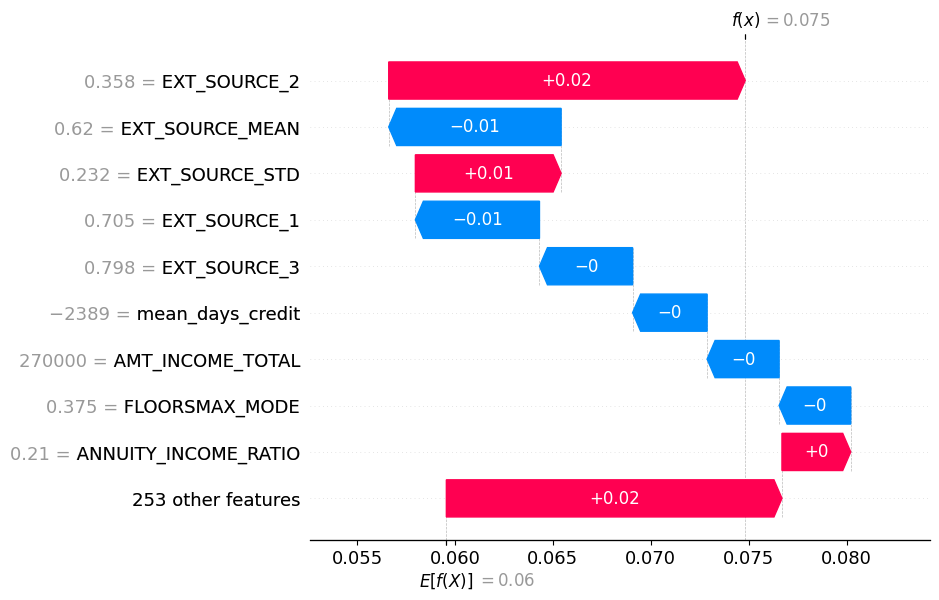

In [73]:
explainer_low = shap.Explainer(best_model.predict_proba, low_probability_applicants)
low_risk_shap = explainer_low(low_probability_subject)
shap.plots.waterfall(low_risk_shap[:, :, 1][0])

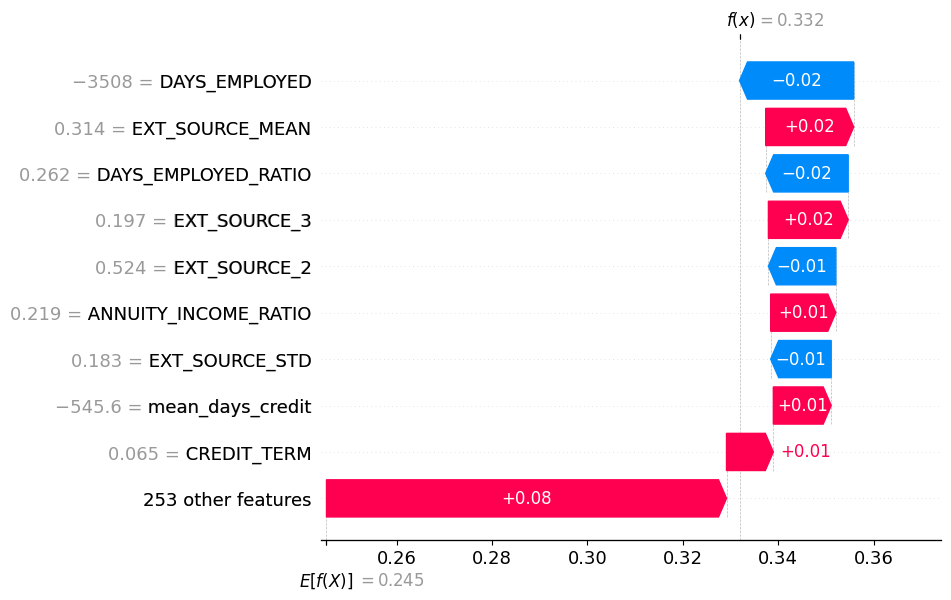

In [72]:
explainer_borderline = shap.Explainer(best_model.predict_proba, borderline_probability_applicants)
borderline_risk_shap = explainer_borderline(borderline_probability_subject)
shap.plots.waterfall(borderline_risk_shap[:, :, 1][0])

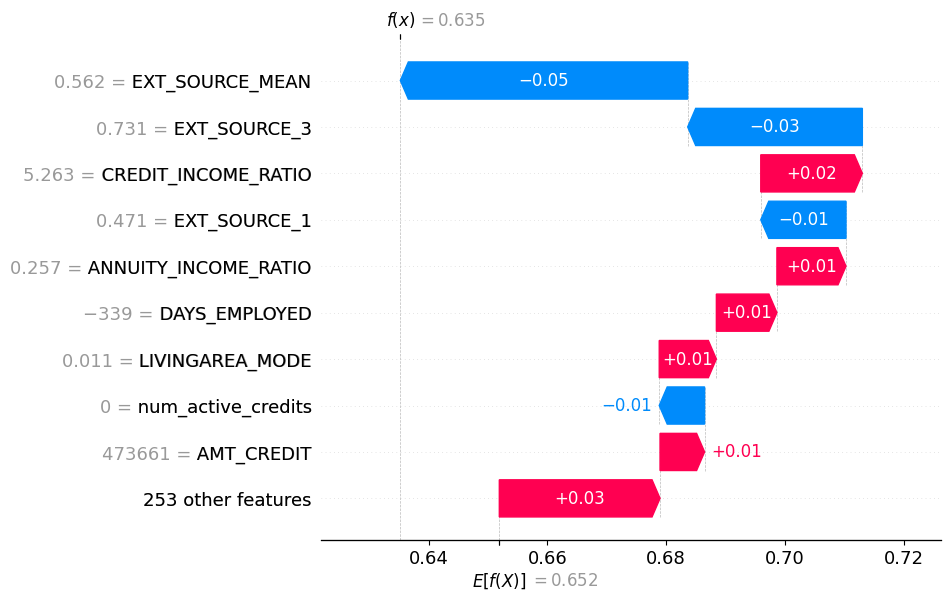

In [71]:
explainer_high = Explainer(best_model.predict_proba, high_probability_applicants)
high_probability_shap = explainer_high(high_probability_subject)
shap.plots.waterfall(high_probability_shap[:, :, 1][0])

After having generated the SHAP waterfall plots for the tree individual applicants, we now look at how to interpet said plots
- The vertical expected value line $E[f(x)]$ is the baseline value, then we see how each feature either positively/negatively contributes to the final overall probability of whether an applicant will default
- Positive push is indicated by a red arrow to the right, negative push is indicated by a blue arrow to the left

## Adverse action notice - high risk applicant

According to the Equal Credit Opportunity Act (ECOA), specific reasoning must be provided when denying credit. Based on the waterfall plot, we can identify 4 such features for the high likelihood applicant:
- Credit to income ratio above threshold for approval (e.g. threshold = 3.0, actual > 5.0)
- Amount of credit above threshold for approval (e.g. threshold = \$200000, actual > \$400000)
- Annuity to income ratio above threshold for approval (e.g. threshold = 0.225, actual > 0.250)
- Has not been employed for long enough duration (e.g. days since employed = 339, minimum > 1000)

## Compute Population Stability Index (PSI) between training and test distributions for the top 10 features. Flag any with PSI > 0.25 (indicating distribution shift)

First compute top 10 features

In [27]:
# create Series/DataFrame with feature importances
feature_importances = pd.DataFrame(data=best_model.named_steps['model'].feature_importances_, index=X_sample_normalized.columns).rename(columns={0: 'Importance Score'})

In [28]:
top_10_features = feature_importances.sort_values(by=['Importance Score'], ascending=False).head(10).index
top_10_features

Index(['EXT_SOURCE_MEAN', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_STD', 'ANNUITY_INCOME_RATIO', 'mean_days_credit',
       'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'DAYS_EMPLOYED'],
      dtype='object')

Next up, we define PSI as `sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))`

In [37]:
def compute_PSI(training_data, testing_data, bins=10):
#     split data into bins

    breakpoints = np.unique(np.quantile(training_data, np.linspace(0, 1, bins + 1)))
    
    # get the counts/distribution per biin for training and test data
    expected_counts = pd.cut(training_data, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    actual_counts = pd.cut(testing_data, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()
    psi = ((actual_pct - expected_pct) *
           np.log(actual_pct / expected_pct)).sum()

    return psi

In [38]:
psi_results = {}
for feature in top_10_features:
    psi_results[feature] = compute_PSI(X_train[feature], X_test[feature], bins=10)

psi_results

{'EXT_SOURCE_MEAN': 0.006076609170987724,
 'EXT_SOURCE_3': 0.0060630626499840684,
 'EXT_SOURCE_1': 0.00635209472199195,
 'EXT_SOURCE_2': 0.003192569414330169,
 'EXT_SOURCE_STD': 0.006726514510443322,
 'ANNUITY_INCOME_RATIO': 0.008401475466939956,
 'mean_days_credit': 0.00731188963620593,
 'CREDIT_TERM': 0.00022503317200325208,
 'DAYS_EMPLOYED_RATIO': 0.0025195633235322265,
 'DAYS_EMPLOYED': 0.0046132995200257685}

## Create a model monitoring dashboard: a summary figure showing (a) AUROC by validation fold, (b) top 10 feature importances, (c) PSI heatmap.

In [31]:
feature_importances_sorted = feature_importances.sort_values(by=['Importance Score'], ascending=False).head(10)
features = feature_importances_sorted.index
feature_scores = feature_importances_sorted['Importance Score']

display(feature_importances_sorted)
display(features)
display(feature_scores)

,Importance Score
EXT_SOURCE_MEAN,0.074257
EXT_SOURCE_3,0.042106
EXT_SOURCE_1,0.041682
EXT_SOURCE_2,0.038939
EXT_SOURCE_STD,0.023426
ANNUITY_INCOME_RATIO,0.020639
mean_days_credit,0.019885
CREDIT_TERM,0.019110
DAYS_EMPLOYED_RATIO,0.018482
DAYS_EMPLOYED,0.018140


Index(['EXT_SOURCE_MEAN', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_STD', 'ANNUITY_INCOME_RATIO', 'mean_days_credit',
       'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'DAYS_EMPLOYED'],
      dtype='object')

EXT_SOURCE_MEAN         0.074257
EXT_SOURCE_3            0.042106
EXT_SOURCE_1            0.041682
EXT_SOURCE_2            0.038939
EXT_SOURCE_STD          0.023426
ANNUITY_INCOME_RATIO    0.020639
mean_days_credit        0.019885
CREDIT_TERM             0.019110
DAYS_EMPLOYED_RATIO     0.018482
DAYS_EMPLOYED           0.018140
Name: Importance Score, dtype: float64

In [44]:
psi_df = pd.DataFrame(pd.Series(data=psi_results, index=psi_results.keys())).rename(columns={0: 'PSI'})
psi_df

,PSI
EXT_SOURCE_MEAN,0.006077
EXT_SOURCE_3,0.006063
EXT_SOURCE_1,0.006352
EXT_SOURCE_2,0.003193
EXT_SOURCE_STD,0.006727
ANNUITY_INCOME_RATIO,0.008401
mean_days_credit,0.007312
CREDIT_TERM,0.000225
DAYS_EMPLOYED_RATIO,0.002520
DAYS_EMPLOYED,0.004613


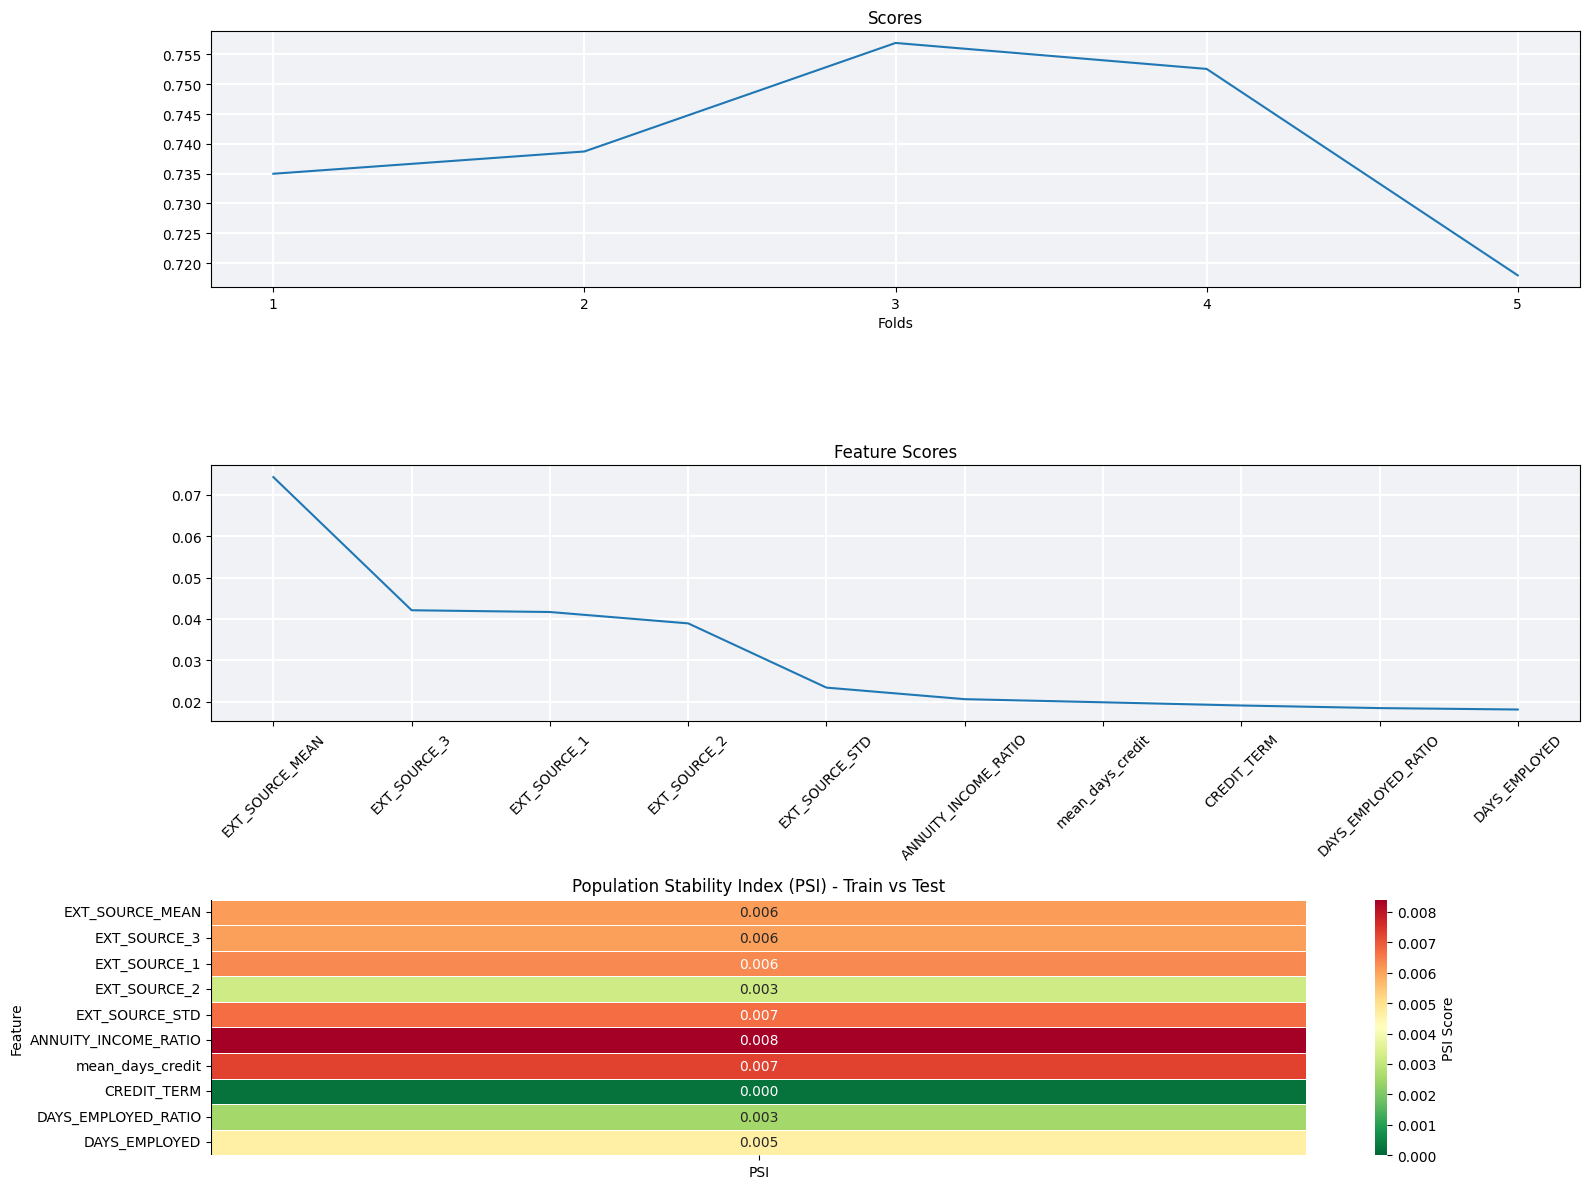

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# give all plots equal space (make them all centred)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 1, 1]})

axes[0].plot(range(1, 6), scores)
axes[0].set_title("Scores")
axes[0].set_xlabel("Folds")
axes[0].set_xticks(range(1, 6))

axes[0].grid(
    visible=True,       
    which='major',     
    axis='both',       
    color='white',      
    linestyle='-',     
    linewidth=1.5,      
    alpha=1.0           
)
axes[0].set_facecolor("#f0f2f6")

axes[1].plot(features, feature_scores)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Feature Scores")

axes[1].grid(
    visible=True,       
    which='major',     
    axis='both',       
    color='white',      
    linestyle='-',     
    linewidth=1.5,      
    alpha=1.0           
)
axes[1].set_facecolor("#f0f2f6")

sns.heatmap(
    psi_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    linewidths=0.5,
    cbar_kws={"label": "PSI Score"},
    ax=axes[2]
)

axes[2].axvline(0, color="black")
axes[2].set_title("Population Stability Index (PSI) - Train vs Test")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.show()